In [201]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import time

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/taweilo/loan-approval-classification-data/loan_data.csv


In [202]:
df = pd.read_csv("/kaggle/input/datasets/taweilo/loan-approval-classification-data/loan_data.csv")

In [203]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [204]:
df.shape

(45000, 14)

In [205]:
from sklearn.model_selection import train_test_split

In [206]:
x = df.iloc[:,0:13]
y = df.iloc[:,-1]

In [207]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [208]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36000 entries, 26923 to 8093
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      36000 non-null  float64
 1   person_gender                   36000 non-null  object 
 2   person_education                36000 non-null  object 
 3   person_income                   36000 non-null  float64
 4   person_emp_exp                  36000 non-null  int64  
 5   person_home_ownership           36000 non-null  object 
 6   loan_amnt                       36000 non-null  float64
 7   loan_intent                     36000 non-null  object 
 8   loan_int_rate                   36000 non-null  float64
 9   loan_percent_income             36000 non-null  float64
 10  cb_person_cred_hist_length      36000 non-null  float64
 11  credit_score                    36000 non-null  int64  
 12  previous_loan_defaults_on_file  36

In [209]:
def outliers(df, columns):
    df = df.copy()

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = df[col].clip(lower=lower, upper=upper)

    return df

In [210]:
x_train_num = x_train.select_dtypes(include="number")
x_train_num = outliers(x_train_num,x_train_num.columns)
x_train_cat = x_train.select_dtypes(include="object")
scale_train_col = [x_train.columns.get_loc(i) for i in x_train_num.columns]
cat_train_col = [x_train.columns.get_loc(i) for i in x_train_cat.columns]

In [211]:
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


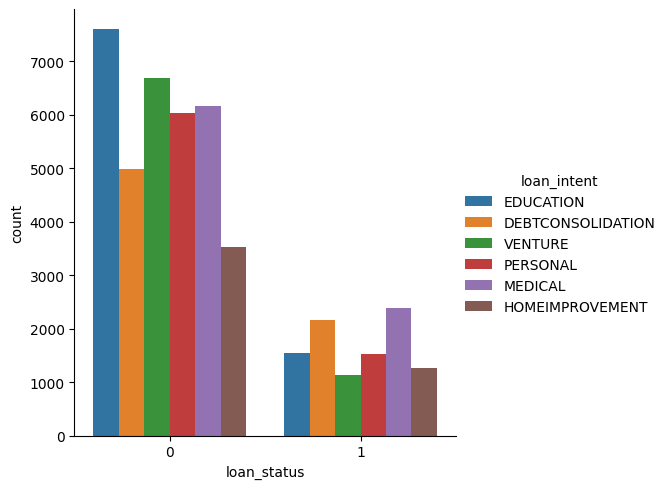

In [212]:
ss.catplot(x='loan_status',hue='loan_intent', data=df, kind='count')

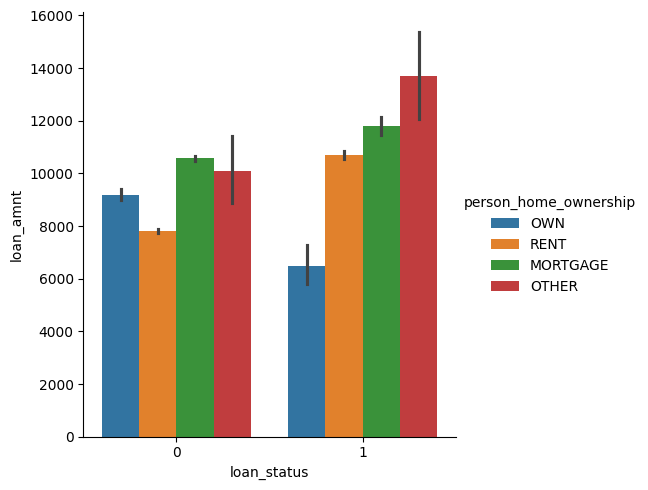

In [213]:
ss.catplot(x='loan_status', y='loan_amnt',hue="person_home_ownership", data=df, kind='bar')

In [214]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

In [215]:
from sklearn.preprocessing import StandardScaler , OneHotEncoder , PowerTransformer
import matplotlib.pyplot as mp
import seaborn as ss

In [216]:
trf1 = ColumnTransformer(transformers=[
    ('ohe',OneHotEncoder(sparse_output=False),cat_train_col)
],remainder='passthrough')

In [217]:
trf2 = ColumnTransformer(transformers=[
    ('scale',StandardScaler(),scale_train_col)
],remainder='passthrough')

In [218]:
trf3 = ColumnTransformer(transformers=[
    ('log',PowerTransformer(method="yeo-johnson"),scale_train_col)
],remainder='passthrough')

In [219]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

In [220]:
from sklearn.ensemble import BaggingClassifier

In [221]:
trf4 = LogisticRegression()
trf5 = DecisionTreeClassifier(criterion='entropy',max_depth=10,splitter='best')
trf6 = BaggingClassifier(estimator=DecisionTreeClassifier())

In [222]:
pipe_log = make_pipeline(trf1,trf2,trf3,trf4)
pipe_dt = make_pipeline(trf1,trf2,trf3,trf5)
pipe_bag = make_pipeline(trf1,trf2,trf3,trf6)

In [223]:
pipe_log.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(sparse_output=False),
                                                  [1, 2, 5, 7, 12])])),
                ('columntransformer-2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scale', StandardScaler(),
                                                  [0, 3, 4, 6, 8, 9, 10,
                                                   11])])),
                ('columntransformer-3',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('log', PowerTransformer(),
                                                  [0, 3, 4, 6, 8, 9, 10,
                                                   11])])),
                ('logisticregression', LogisticRegression())])

In [224]:
pred = pipe_log.predict(x_test)

In [225]:
from sklearn.metrics import accuracy_score,precision_score,recall_score
from sklearn.model_selection import GridSearchCV , cross_val_score

In [226]:
a = cross_val_score(pipe_log,x_train,y_train,cv=10,scoring="accuracy")
np.mean(a)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

np.float64(0.8451666666666668)

In [227]:
b = cross_val_score(pipe_dt,x_train,y_train,cv=10,scoring="accuracy")
np.mean(b)

np.float64(0.9211944444444444)

In [228]:
paramater = {
    'decisiontreeclassifier__criterion' : ['gini','entropy'],
    'decisiontreeclassifier__splitter' : ['best','random'],
    'decisiontreeclassifier__max_depth' : [3,5,10,15,20]
}

In [229]:
from sklearn.model_selection import GridSearchCV

In [230]:
a = GridSearchCV(pipe_dt,param_grid=paramater,cv=10)

In [231]:
a.fit(x_train,y_train)
a.best_params_

{'decisiontreeclassifier__criterion': 'entropy',
 'decisiontreeclassifier__max_depth': 10,
 'decisiontreeclassifier__splitter': 'best'}

In [232]:
param_grid = {
    'baggingclassifier__n_estimators': [10, 50, 100],
    'baggingclassifier__max_samples': [0.5, 0.7, 1.0],
    'baggingclassifier__max_features': [0.5, 1.0],
    'baggingclassifier__estimator__max_depth': [3, 5, 10],
    'baggingclassifier__estimator__criterion': ['gini', 'entropy']
}

In [233]:
grid = GridSearchCV(pipe_bag,param_grid,cv=10,scoring="accuracy",n_jobs=-1)

In [234]:
start = time.time()
grid.fit(x_train,y_train)
end = time.time()

In [235]:
grid.best_score_

np.float64(0.9265277777777777)

In [300]:
sample = pd.DataFrame({
    'person_age' : [24,32,21],
    'person_gender' : ['male','female','male'],
    'person_education' : ['Bachelor','High School','Associate'],
    'person_income' : [118460.0	,6500,50000],
    'person_emp_exp' : [3,12,3],
    'person_home_ownership' : ['RENT','MORTGAGE','RENT'],
    'loan_amnt' : [14000.0	,3200,7000],
    'loan_intent' : ['EDUCATION','MEDICAL','MEDICAL'],
    'loan_int_rate' : [14.26,12.45,12],
    'loan_percent_income' : [0.12,0.17,0.21],
    'cb_person_cred_hist_length' : [3.0,5,3],
    'credit_score' : [614,450,430],
    'previous_loan_defaults_on_file' : ['No','No','No']
})

In [301]:
grid.predict(sample)

array([0, 1, 1])

In [302]:
grid.predict_proba(sample)

array([[0.53698694, 0.46301306],
       [0.        , 1.        ],
       [0.25002455, 0.74997545]])